In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

# =========================================================
# 1. LOAD MODEL DAN PERALATAN PRE-PROCESSING
# =========================================================
print("Loading Model CNN dan Scaler...")
model = tf.keras.models.load_model('../models/runform_model.h5')
scaler = joblib.load('../models/scaler.pkl')
encoder = joblib.load('../models/label_encoder.pkl')

# Inisialisasi BlazePose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Fungsi hitung sudut lutut (Sama persis seperti di Notebook 01)
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

# =========================================================
# 2. SETUP VIDEO TESTING
# =========================================================
VIDEO_PATH = '../data/testingting.mp4' # <--- GANTI DENGAN VIDEO BARU ANDA
cap = cv2.VideoCapture(VIDEO_PATH)

# (Opsional) Jika ingin menyimpan hasil analisis menjadi video baru
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
out = cv2.VideoWriter('../data/results/output_test.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (frame_width, frame_height))

print("\nMemulai Analisis Video Frame-by-Frame...")
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    # Konversi untuk MediaPipe
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    
    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark
        
        # Hitung Sudut Lutut
        hip = [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y]
        knee = [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y]
        ankle = [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y]
        knee_angle = calculate_angle(hip, knee, ankle)
        
        # EKSTRAKSI 133 FITUR (Urutan harus persis seperti saat training)
        features = [knee_angle]
        for lm in landmarks:
            features.extend([lm.x, lm.y, lm.z, lm.visibility])
            
        # Convert ke array 2D
        features_array = np.array(features).reshape(1, -1)
        
        # 1. Standarisasi (Scaler)
        features_scaled = scaler.transform(features_array)
        
        # 2. Reshape ke 3D untuk input CNN 1D
        features_cnn = np.expand_dims(features_scaled, axis=2)
        
        # 3. Prediksi Klasifikasi
        pred_probs = model.predict(features_cnn, verbose=0)
        pred_index = np.argmax(pred_probs, axis=1)[0]
        pred_label = encoder.inverse_transform([pred_index])[0]
        confidence = np.max(pred_probs) * 100
        
        # Cetak hasil ke terminal tiap 10 frame agar tidak penuh
        if frame_count % 10 == 0:
            print(f"Frame {frame_count} | Prediksi: {pred_label} ({confidence:.2f}%)")
            
        # [OPSIONAL] Tulis teks hasil prediksi di atas video
        cv2.putText(frame, f'{pred_label} ({confidence:.1f}%)', (50, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
    
    # [OPSIONAL] Simpan frame ke video output
    out.write(frame)
    frame_count += 1

cap.release()
# out.release()
print("\nPengujian Selesai!")

Loading Model CNN dan Scaler...

Memulai Analisis Video Frame-by-Frame...
Frame 0 | Prediksi: Normal (100.00%)
Frame 10 | Prediksi: Normal (100.00%)
Frame 20 | Prediksi: Normal (100.00%)
Frame 30 | Prediksi: Normal (100.00%)
Frame 40 | Prediksi: Normal (100.00%)
Frame 50 | Prediksi: Normal (100.00%)
Frame 60 | Prediksi: Normal (100.00%)
Frame 70 | Prediksi: Normal (100.00%)
Frame 80 | Prediksi: Normal (100.00%)


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x14aceb9a0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.10/3.10.20/Frameworks/Python.framework/Versions/3.10/lib/python3.10/weakref.py", line 370, in remove
    def remove(k, selfref=ref(self)):
KeyboardInterrupt: 


Frame 90 | Prediksi: Normal (100.00%)
Frame 100 | Prediksi: Normal (100.00%)
Frame 110 | Prediksi: Normal (100.00%)
Frame 120 | Prediksi: Normal (100.00%)
Frame 130 | Prediksi: Normal (100.00%)
Frame 140 | Prediksi: Normal (100.00%)
Frame 150 | Prediksi: Normal (100.00%)
Frame 160 | Prediksi: Normal (100.00%)
Frame 170 | Prediksi: Normal (100.00%)
Frame 180 | Prediksi: Normal (100.00%)
Frame 190 | Prediksi: Normal (100.00%)
Frame 200 | Prediksi: Normal (100.00%)
Frame 210 | Prediksi: Normal (100.00%)
Frame 220 | Prediksi: Normal (100.00%)
Frame 230 | Prediksi: Normal (100.00%)
Frame 240 | Prediksi: Normal (100.00%)
Frame 250 | Prediksi: Normal (100.00%)
Frame 260 | Prediksi: Normal (100.00%)
Frame 270 | Prediksi: Normal (100.00%)
Frame 280 | Prediksi: Normal (100.00%)
Frame 290 | Prediksi: Normal (100.00%)
Frame 300 | Prediksi: Normal (100.00%)
Frame 310 | Prediksi: Normal (100.00%)
Frame 320 | Prediksi: Normal (100.00%)
Frame 330 | Prediksi: Normal (100.00%)
Frame 340 | Prediksi: Norm

Loading Model CNN dan Scaler...

Memulai Analisis Visual...
Gambar tersimpan: ../data/results/inference_images/frame_0_Normal.jpg


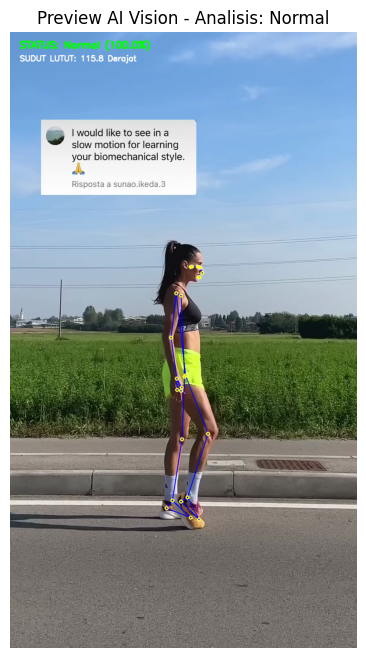

Gambar tersimpan: ../data/results/inference_images/frame_15_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_30_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_45_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_60_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_75_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_90_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_105_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_120_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_135_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_150_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_165_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_180_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_195_Normal.jpg
Gambar tersimpan: ../data/results/inference_images/frame_210_Normal.jp

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import os
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD MODEL DAN PERALATAN PRE-PROCESSING
# =========================================================
print("Loading Model CNN dan Scaler...")
model = tf.keras.models.load_model('../models/runform_model.h5')
scaler = joblib.load('../models/scaler.pkl')
encoder = joblib.load('../models/label_encoder.pkl')

# Inisialisasi BlazePose dan Drawing Utils
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils # <--- TAMBAHAN UNTUK MENGGAMBAR SKELETON

# Buat direktori khusus untuk menyimpan gambar hasil uji coba
OUTPUT_DIR = '../data/results/inference_images/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fungsi hitung sudut lutut
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

# =========================================================
# 2. SETUP VIDEO TESTING
# =========================================================
VIDEO_PATH = '../data/testingting.mp4' # <--- GANTI DENGAN VIDEO BARU ANDA
cap = cv2.VideoCapture(VIDEO_PATH)

print("\nMemulai Analisis Visual...")
frame_count = 0
image_displayed = False

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    
    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark
        
        # Hitung Sudut Lutut
        hip = [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y]
        knee = [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y]
        ankle = [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y]
        knee_angle = calculate_angle(hip, knee, ankle)
        
        # Ekstraksi Fitur
        features = [knee_angle]
        for lm in landmarks:
            features.extend([lm.x, lm.y, lm.z, lm.visibility])
            
        # Prediksi Klasifikasi
        features_array = np.array(features).reshape(1, -1)
        features_scaled = scaler.transform(features_array)
        features_cnn = np.expand_dims(features_scaled, axis=2)
        
        pred_probs = model.predict(features_cnn, verbose=0)
        pred_index = np.argmax(pred_probs, axis=1)[0]
        pred_label = encoder.inverse_transform([pred_index])[0]
        confidence = np.max(pred_probs) * 100
        
        # =========================================================
        # 3. VISUALISASI PADA GAMBAR (OVERLAY)
        # =========================================================
        # A. Gambar garis dan titik sendi pada tubuh
        mp_drawing.draw_landmarks(
            frame, 
            results.pose_landmarks, 
            mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,255), thickness=2, circle_radius=4), # Titik Kuning
            mp_drawing.DrawingSpec(color=(255,0,0), thickness=2, circle_radius=2)    # Garis Biru
        )
        
        # B. Tentukan warna teks (Hijau jika Normal, Merah jika Salah)
        text_color = (0, 255, 0) if pred_label == 'Normal' else (0, 0, 255)
        
        # C. Tulis Label, Confidence, dan Sudut di atas frame video
        cv2.putText(frame, f'STATUS: {pred_label} ({confidence:.1f}%)', (30, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, text_color, 3, cv2.LINE_AA)
        cv2.putText(frame, f'SUDUT LUTUT: {knee_angle:.1f} Derajat', (30, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
        
        # =========================================================
        # 4. SIMPAN GAMBAR KE FOLDER
        # =========================================================
        # Kita simpan setiap kelipatan 15 frame (sekitar 2 frame per detik) agar folder tidak penuh
        if frame_count % 15 == 0:
            image_filename = os.path.join(OUTPUT_DIR, f'frame_{frame_count}_{pred_label}.jpg')
            cv2.imwrite(image_filename, frame)
            print(f"Gambar tersimpan: {image_filename}")
            
            # Tampilkan 1 gambar pertama langsung di Jupyter Notebook sebagai preview
            if not image_displayed:
                plt.figure(figsize=(12, 8))
                plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                plt.title(f"Preview AI Vision - Analisis: {pred_label}")
                plt.axis('off')
                plt.show()
                image_displayed = True
                
    frame_count += 1

cap.release()
print("\nPengujian Selesai! Cek folder '../data/results/inference_images/' untuk melihat semua gambar hasil jepretan AI.")

In [ ]:
// =========================================================

In [7]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import os
from tqdm import tqdm # Untuk menampilkan progress bar

# =========================================================
# 1. LOAD MODEL DAN PERALATAN PRE-PROCESSING
# =========================================================
print("Loading Model CNN dan Scaler...")
model = tf.keras.models.load_model('../models/runform_model.h5')
scaler = joblib.load('../models/scaler.pkl')
encoder = joblib.load('../models/label_encoder.pkl')

# Inisialisasi BlazePose dan Drawing Utils
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils

# Fungsi hitung sudut lutut
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

# =========================================================
# 2. SETUP VIDEO INPUT & OUTPUT
# =========================================================
INPUT_VIDEO_PATH = '../data/testing_kesekian.mp4' # <--- GANTI DENGAN VIDEO UJI ANDA
OUTPUT_DIR = '../data/results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_VIDEO_PATH = os.path.join(OUTPUT_DIR, 'hasil_testing_kesekian.mp4') # <--- Hasil Video Uji

cap = cv2.VideoCapture(INPUT_VIDEO_PATH)

# Mengambil properti video asli agar outputnya memiliki kualitas dan kecepatan yang sama
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'avc1')
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (frame_width, frame_height))

print(f"\nMemulai Analisis Video ({total_frames} frames)...")

# Menggunakan tqdm agar Anda bisa melihat persentase proses rendering
with tqdm(total=total_frames, desc="Rendering Video") as pbar:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image_rgb.flags.writeable = False # Optimasi performa
        results = pose.process(image_rgb)
        
        # Variabel default jika AI tidak menemukan subjek
        status_text = "MENUNGGU SUBJEK..."
        text_color = (200, 200, 200) # Abu-abu
        confidence = 0.0
        knee_angle = 0.0
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            
            # Hitung Sudut Lutut
            hip = [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y]
            knee = [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y]
            ankle = [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y]
            knee_angle = calculate_angle(hip, knee, ankle)
            
            # Ekstraksi Fitur
            features = [knee_angle]
            for lm in landmarks:
                features.extend([lm.x, lm.y, lm.z, lm.visibility])
                
            # Prediksi Klasifikasi
            features_array = np.array(features).reshape(1, -1)
            features_scaled = scaler.transform(features_array)
            features_cnn = np.expand_dims(features_scaled, axis=2)
            
            pred_probs = model.predict(features_cnn, verbose=0)
            pred_index = np.argmax(pred_probs, axis=1)[0]
            pred_label = encoder.inverse_transform([pred_index])[0]
            confidence = np.max(pred_probs) * 100
            
            # =========================================================
            # 3. MENGGAMBAR OVERLAY (DI ATAS FRAME)
            # =========================================================
            # Gambar Skeleton
            mp_drawing.draw_landmarks(
                frame, 
                results.pose_landmarks, 
                mp_pose.POSE_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(0,255,255), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(255,0,0), thickness=2, circle_radius=2)
            )
            
            # Tentukan Warna Status
            status_text = f'STATUS: {pred_label} ({confidence:.1f}%)'
            if pred_label == 'Normal':
                text_color = (0, 255, 0) # Hijau
            elif pred_label == 'Overstride':
                text_color = (0, 0, 255) # Merah
            elif pred_label == 'Heel_Strike':
                text_color = (0, 165, 255) # Orange (BGR)
                
        # =========================================================
        # 4. TAMPILKAN TEKS & TULIS KE VIDEO OUTPUT
        # =========================================================
        # Tambahkan background hitam transparan agar teks mudah dibaca
        cv2.rectangle(frame, (15, 15), (600, 120), (0, 0, 0), -1)
        
        cv2.putText(frame, status_text, (30, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, text_color, 3, cv2.LINE_AA)
        
        if results.pose_landmarks:
            cv2.putText(frame, f'SUDUT LUTUT: {knee_angle:.1f} Derajat', (30, 95), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
            
        # Simpan frame yang sudah diedit ke dalam file video baru
        out.write(frame)
        
        # Update progress bar
        pbar.update(1)

# Bersihkan memori
cap.release()
out.release()
print(f"\nRender Selesai! Video output disimpan di: {OUTPUT_VIDEO_PATH}")

Loading Model CNN dan Scaler...

Memulai Analisis Video (361 frames)...


Rendering Video: 100%|██████████| 361/361 [00:13<00:00, 26.27it/s]



Render Selesai! Video output disimpan di: ../data/results/hasil_testing_kesekian.mp4
